In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/utkarshsahare/students-performance/StudentsPerformance.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv(r'/kaggle/input/datasets/utkarshsahare/students-performance/StudentsPerformance.csv')

In [4]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
df.shape

(1000, 8)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


# EDA

In [7]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [8]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [9]:
categories = ['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course']
for i in categories:
    print(df[i].value_counts())
    print('♠️'*30)

gender
female    518
male      482
Name: count, dtype: int64
♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️
race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64
♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️
parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64
♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️
lunch
standard        645
free/reduced    355
Name: count, dtype: int64
♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️
test preparation course
none         642
completed    358
Name: count, dtype: int64
♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️♠️


# Univariate plots

In [10]:
sns.color_palette()

[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
 (0.7372549019607844, 0.7411764705882353, 0.13333333333333333),
 (0.09019607843137255, 0.7450980392156863, 0.8117647058823529)]

In [11]:
sns.color_palette("pastel6").as_hex()

['#a1c9f4', '#8de5a1', '#ff9f9b', '#d0bbff', '#fffea3', '#b9f2f0']

In [12]:
pal = ['#FFC20A','#0C7BDC','#994F00','#006CD1','#40B0A6','#bdcf32','#27aeef']

<Axes: xlabel='gender', ylabel='count'>

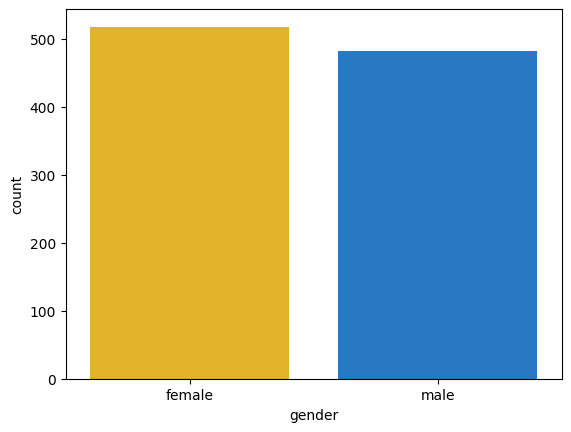

In [13]:
sns.barplot(x=df['gender'].value_counts().index,
            y=df['gender'].value_counts(),
            hue = df['gender'].value_counts().index,
            palette = pal[:2],
            legend = False
            
           )

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


<Axes: xlabel='None'>

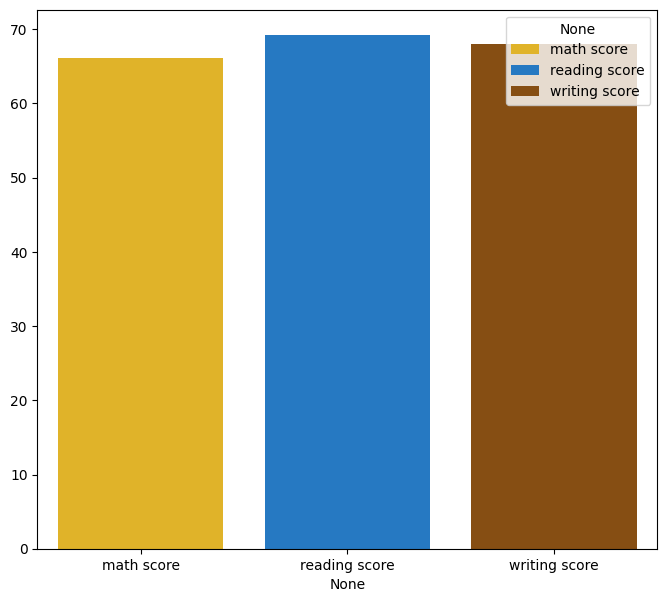

In [15]:
numeric_df = df.select_dtypes(include=['number'])
means = numeric_df.mean()
plt.figure(figsize = (8,7))
sns.barplot(x=means.index,
           y=means.values,
            hue= means.index,
            legend=True,
            palette = pal[:len(means)])


In [16]:
print(len(means))

3


In [17]:
print(means)

math score       66.089
reading score    69.169
writing score    68.054
dtype: float64


Text(0.5, 1.0, 'Students Average Score')

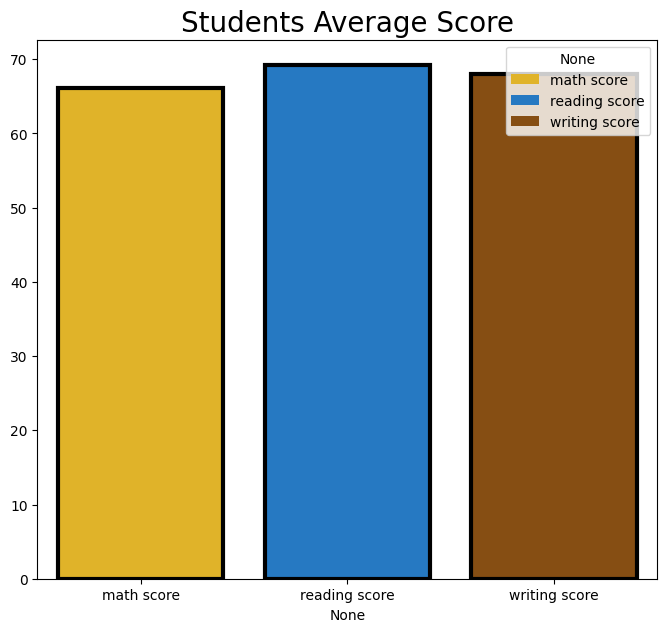

In [18]:
numeric_df = df.select_dtypes(include=['number'])
means = numeric_df.mean()
plt.figure(figsize = (8,7))
ax = sns.barplot(x=means.index,
           y=means.values,
            hue= means.index,
            legend=True,
            palette = pal[:len(means)])
for bar in ax.patches:
    bar.set_linewidth(3)
    bar.set_edgecolor('black')
plt.title('Students Average Score', fontsize=20)

### what happens if we simply change the axis ?

Text(0.5, 1.0, 'Students Average Score')

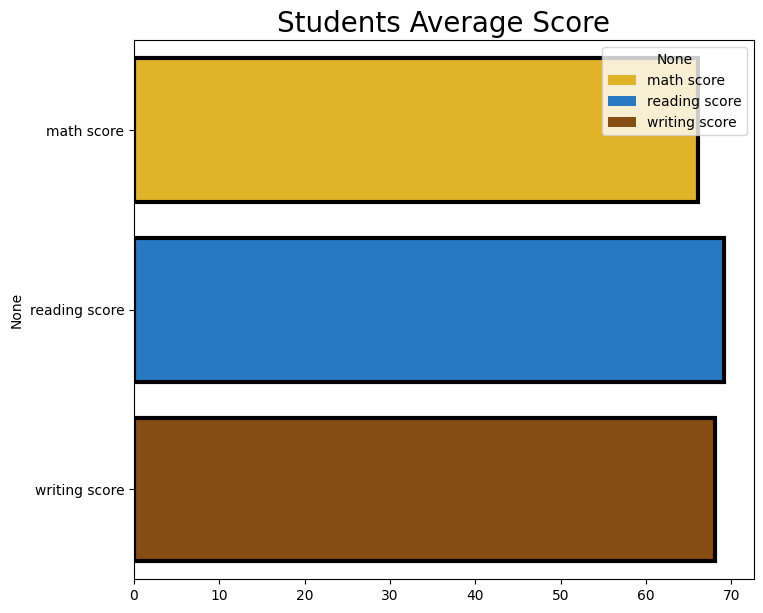

In [19]:
numeric_df = df.select_dtypes(include=['number'])
means = numeric_df.mean()
plt.figure(figsize = (8,7))
ax = sns.barplot(x=means.values,
           y=means.index,
            hue= means.index,
            legend=True,
            palette = pal[:len(means)])
for bar in ax.patches:
    bar.set_linewidth(3)
    bar.set_edgecolor('black')
plt.title('Students Average Score', fontsize=20)

# Maths score gender wise

In [20]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

/tmp/ipykernel_17/1538141236.py:1: UserWarning: The palette list has more values (7) than needed (2), which may not be intended.
  sns.barplot(data = df,


<Axes: xlabel='gender', ylabel='math score'>

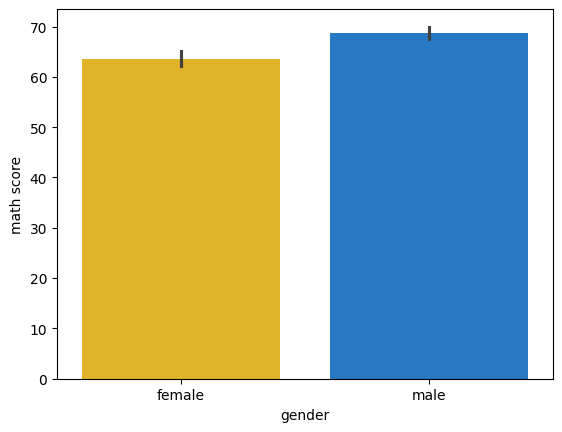

In [21]:
sns.barplot(data = df,
            x='gender',
           y= 'math score',
           hue = 'gender',
           palette = pal)

### Understanding Confidence Intervals (CI)
The **confidence interval** in this graph is represented by the **thin black vertical lines** (error bars) at the top of each bar.

* **The Estimate of Error:** Since your data is a sample, the bar shows the average (mean) math score, while the black line shows the **range** where the *true* population average likely sits.
* **The 95% Rule:** By default, Seaborn uses a **95% confidence interval**. This means if you repeated your study 100 times, the average would fall within that black line 95 times.
* **Reading the Spread:** 
    * **Short line:** You have a lot of data or scores are very similar; you are very certain about the average.
    * **Long line:** Scores vary widely; you are less certain about the exact average.


# lineplot

<Axes: xlabel='reading score', ylabel='math score'>

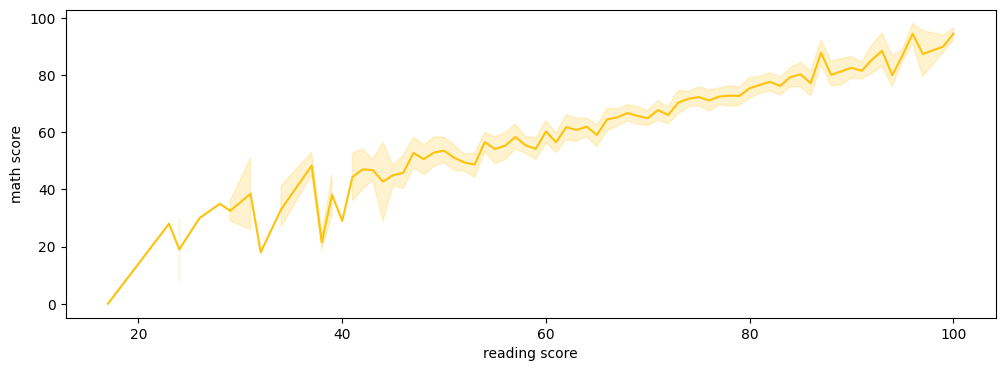

In [22]:
plt.figure(figsize=(12,4))
sns.lineplot(data=df,x='reading score',y='math score',color=pal[0])

## 1. The Default Behavior (95%)
In **Seaborn**, when you plot a line graph with multiple y-values for a single x-value, it automatically aggregates the data. It plots the mean (the solid yellow line) and uses a statistical method called bootstrapping to calculate and shade the 95% confidence interval around that mean (the lighter yellow band).

In [23]:
#plt.figure(figsize=(12,4))
#sns.lineplot(data=df,x='reading score',y='math score',color=pal[0],hue='writing score')

<Axes: xlabel='reading score', ylabel='math score'>

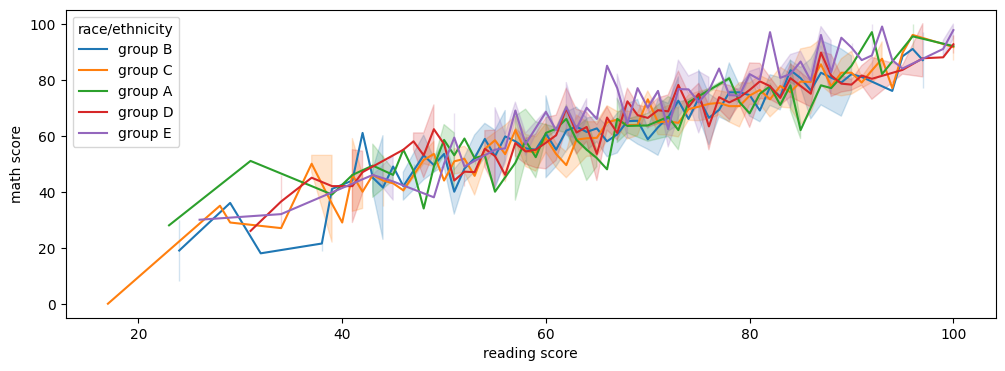

In [24]:
plt.figure(figsize=(12,4))
sns.lineplot(data=df,x='reading score',y='math score',color=pal[0],hue='race/ethnicity')

<Axes: xlabel='reading score', ylabel='math score'>

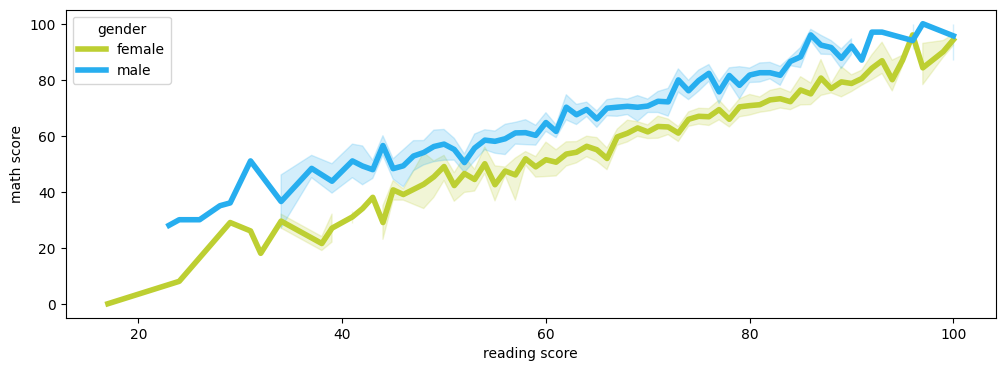

In [25]:
plt.figure(figsize=(12,4))
sns.lineplot(data=df,x='reading score',y='math score',color=pal[0],hue='gender',palette=pal[-2:],lw=4)

In [26]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

# Histplot

<Axes: xlabel='math score', ylabel='Count'>

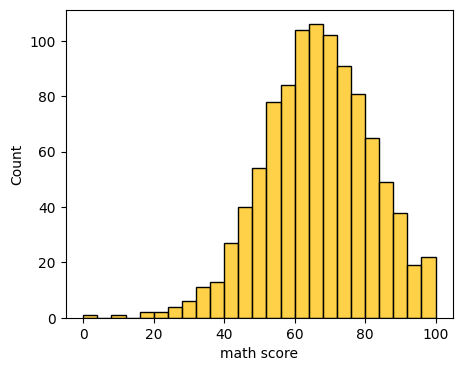

In [27]:
plt.figure(figsize=(5,4))
sns.histplot(data=df,x='math score',stat='count',color=pal[np.random.randint(0,5)])

### changing the stats

## Understanding the `stat` Parameter in Seaborn's `histplot()`

The `stat` keyword dictates exactly **what is calculated and plotted on the y-axis** for each bin of your histogram. Instead of just showing the raw number of data points, you can use it to normalize the data in various ways, making it easier to compare datasets of different sizes or to view the data as a probability distribution.



### The `stat` Options

* **`'count'` (The Default)**
  * **What it does:** Shows the absolute number of observations (rows of data) that fall into each bin.
  * **When to use it:** When you just want to know the raw totals (e.g., "Exactly how many scores fall between 80 and 90?").

* **`'frequency'`**
  * **What it does:** Calculates the number of observations divided by the bin width.
  * **When to use it:** Primarily used when you have bins of *unequal* widths, ensuring that wider bins don't look artificially taller just because they cover a larger range.

* **`'probability'` (or `'proportion'`)**
  * **What it does:** Normalizes the values so that the **heights of all the bars sum to 1**.
  * **When to use it:** When you want to see the fraction of the total dataset that falls into a specific bin (e.g., "What proportion of the total data is in this specific score bracket?").

* **`'percent'`**
  * **What it does:** Exactly the same as `'probability'`, but multiplied by 100. The heights of all bars will **sum to 100**.
  * **When to use it:** When you prefer reading whole percentages on the y-axis (e.g., 25% instead of 0.25).

* **`'density'`**
  * **What it does:** Normalizes the histogram so that the total **area of all the bars sums to 1** (width × height).
  * **When to use it:** This transforms your histogram into a true probability density function (PDF). It is required if you want to accurately overlay a continuous distribution curve (like a KDE or Normal distribution curve) over your bars.

<Axes: xlabel='math score', ylabel='Percent'>

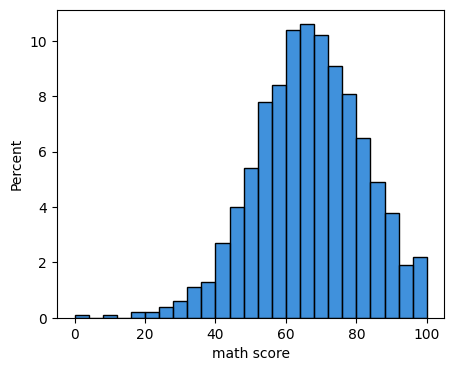

In [28]:
plt.figure(figsize=(5,4))
sns.histplot(data=df,x='math score',stat='percent',color=pal[np.random.randint(0,5)])

<Axes: xlabel='math score', ylabel='Probability'>

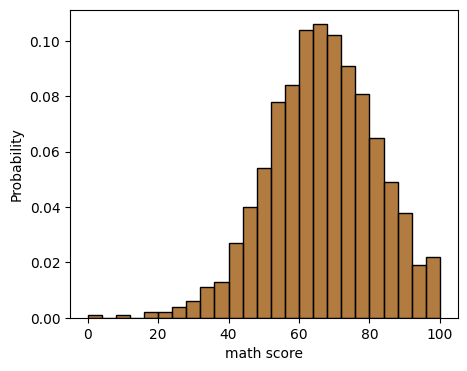

In [29]:
plt.figure(figsize=(5,4))
sns.histplot(data=df,x='math score',stat='probability',color=pal[np.random.randint(0,5)])

<Axes: xlabel='math score', ylabel='Count'>

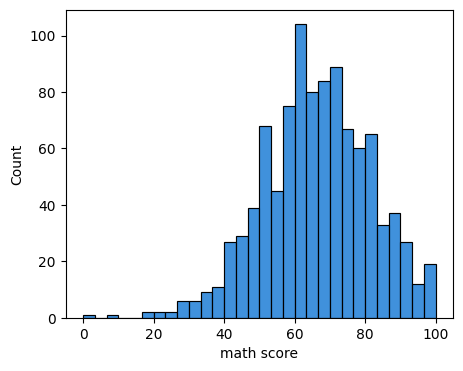

In [30]:
plt.figure(figsize=(5,4))
sns.histplot(data=df,x='math score',bins=30,color=pal[np.random.randint(0,5)])

## **As we increase the number of bins the data gets noiser**

<Axes: xlabel='math score', ylabel='Count'>

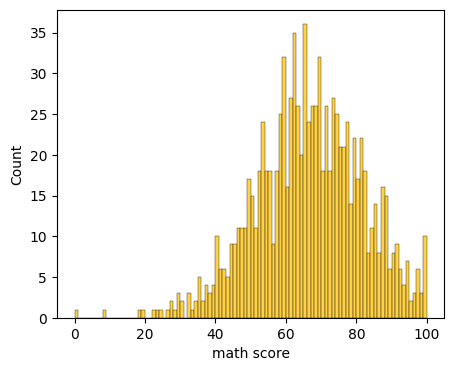

In [31]:
plt.figure(figsize=(5,4))
sns.histplot(data=df,x='math score',bins=100,color=pal[np.random.randint(0,5)])

## Instead we lessens the number of bins and we get smoother graph 

<Axes: xlabel='math score', ylabel='Count'>

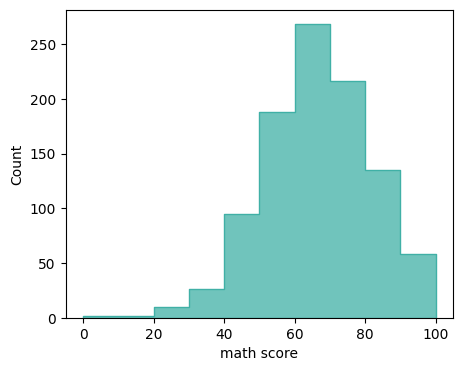

In [32]:
plt.figure(figsize=(5,4))
sns.histplot(data=df,x='math score',element='step',bins=10,color=pal[np.random.randint(0,5)])

## we can get even smoother like a polygon

<Axes: xlabel='math score', ylabel='Count'>

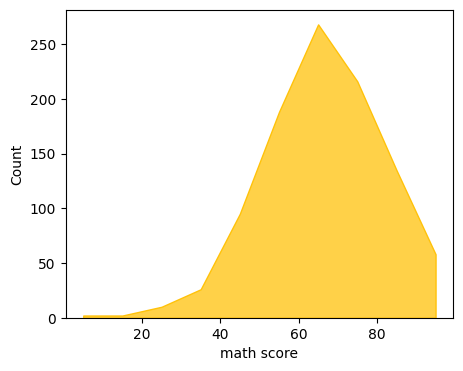

In [33]:
plt.figure(figsize=(5,4))
sns.histplot(data=df,x='math score',element='poly',bins=10,color=pal[np.random.randint(0,5)])

<Axes: xlabel='math score', ylabel='Count'>

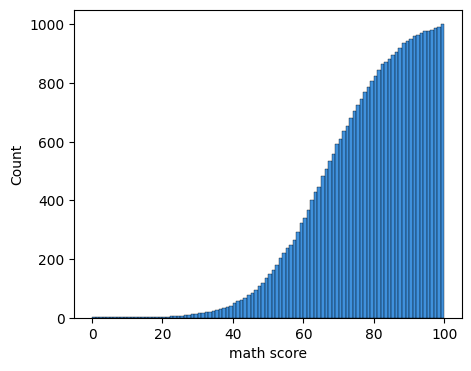

In [34]:
plt.figure(figsize=(5,4))
sns.histplot(data=df,x='math score',bins=100,cumulative = True,color=pal[np.random.randint(0,5)])

## Understanding the Cumulative Histogram

In simple terms, while a regular histogram shows you how many people got *that specific score*, a **cumulative histogram** keeps a running total. It shows you how many people got **that score or lower**. 

Looking at your graph, the bars never go down, and the final bar on the far right reaches a height of 1000. This instantly tells us there are exactly 1,000 data points (e.g., students) in this dataset. 


### The Significance of `cumulative=True`

Turning on the cumulative parameter in your data visualization is incredibly useful for answering specific types of analytical questions at a glance:

* **Finding Thresholds (e.g., "How many failed?"):** If the passing score is 40, you can look at 40 on the x-axis, trace it up to the curve, and see the y-value is roughly 50. That immediately tells you that about 50 students scored a 40 or below.
* **Spotting Percentiles and the Median:** If you want to find the median (the 50th percentile), you just look at the y-axis for 500 (exactly half of your 1000 total students). Trace that across to the bars and down to the x-axis, and you can visually estimate that the median math score is around 66.
* **Analyzing Data Density:** The steepness of the curve tells you where the data is clustered. The graph is relatively flat from 0 to 40, meaning very few students got low scores. It gets incredibly steep between 60 and 80, meaning the vast majority of the students' scores are concentrated in that specific range.

In [35]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

/tmp/ipykernel_17/1799116602.py:2: UserWarning: The palette list has more values (7) than needed (6), which may not be intended.
  sns.histplot(data=df,x='math score',bins=100,cumulative = True,hue='parental level of education',palette=pal)


<Axes: xlabel='math score', ylabel='Count'>

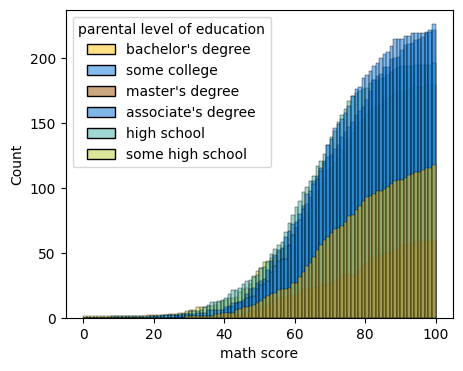

In [36]:
plt.figure(figsize=(5,4))
sns.histplot(data=df,x='math score',bins=100,cumulative = True,hue='parental level of education',palette=pal)

## Understanding the Palette UserWarning

First, the good news: this is just a friendly heads-up from Seaborn, **not an error**. Your code still executed, and your graph still generated perfectly fine!

### What it means

When you use the argument `hue='parental level of education'`, Seaborn looks at your dataset to see how many unique categories exist in that specific column. In your dataset, there are exactly **6 unique levels** of education. 

However, the custom color list (`pal`) you passed to the `palette` argument contains **7 colors**. 

Seaborn is simply telling you: *"Hey, I only needed 6 colors to plot these categories, so I used the first 6 in your list and completely ignored the 7th one. Just making sure this was on purpose!"*

### How to resolve it

Since this doesn't break your code, you have a few easy options:

1. **Do nothing:** You can safely ignore this warning. Seaborn handles the mismatch automatically by just dropping the extra color.
2. **Slice your palette:** If you want to keep your notebook perfectly clean and warning-free, you can tell Python to only pass the exact number of colors Seaborn needs by slicing your list. 

   Just add `[:6]` to the end of your palette variable like this:
   ```python
   # This passes only the first 6 colors from your 'pal' list
   sns.histplot(data=df, x='math score', bins=100, cumulative=True, hue='parental level of education', palette=pal[:6])

<Axes: xlabel='math score', ylabel='Count'>

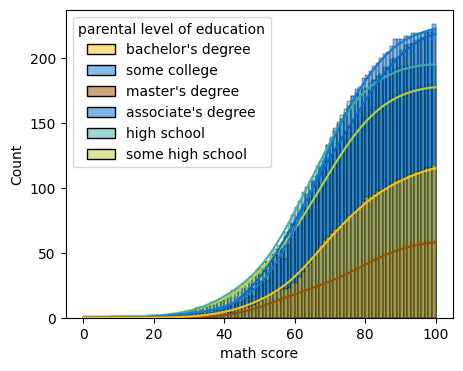

In [37]:
plt.figure(figsize=(5,4))
sns.histplot(data=df,x='math score',bins=100,cumulative = True,hue='parental level of education',kde=True,palette=pal[:6])

<Axes: xlabel='math score', ylabel='Count'>

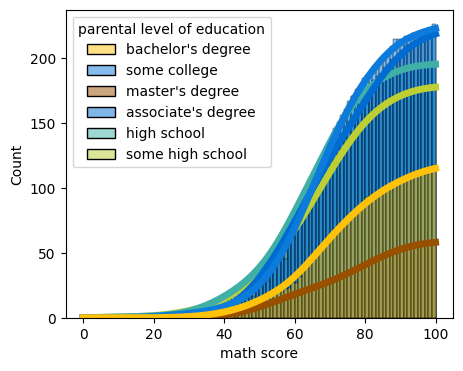

In [38]:
plt.figure(figsize=(5,4))
sns.histplot(data=df,x='math score',line_kws={'lw':5},bins=100,cumulative = True,hue='parental level of education',kde=True,palette=pal[:6])

## Understanding the Grouped Cumulative Histogram

In simple words, this chart takes the "running total" concept from the previous graph and splits it up into different teams—in this case, based on the `parental level of education`. 

Instead of one massive mountain representing all students combined, you now have a separate, smaller hill for each specific group so you can compare them.

Here are the key takeaways you can read from this graph:

* **Finding the Total Group Sizes:** Look at the far right side of the graph (at score 100). The final height of each line tells you exactly how many students belong to that specific category. For example, the top blue line ("some college") reaches the highest, meaning it is the largest group in your dataset (around 220 students). The bottom brown line ("master's degree") is the smallest group (around 60 students).
* **The Smooth Lines:** Those thick, colorful swooshes riding along the bars are smoothed-out trend lines (specifically, a Kernel Density Estimate or KDE). They remove the "blockiness" of the bars to make each group's trajectory easier to track visually.
* **Comparing Score Distributions:** By looking at *when* a specific line starts to curve steeply upward, you can see where that group's scores are concentrated. If a line stays flat near zero for a long time on the left before finally rising, it means very few students in that group received low math scores.

In [39]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

# kdeplot

<Axes: xlabel='writing score', ylabel='Density'>

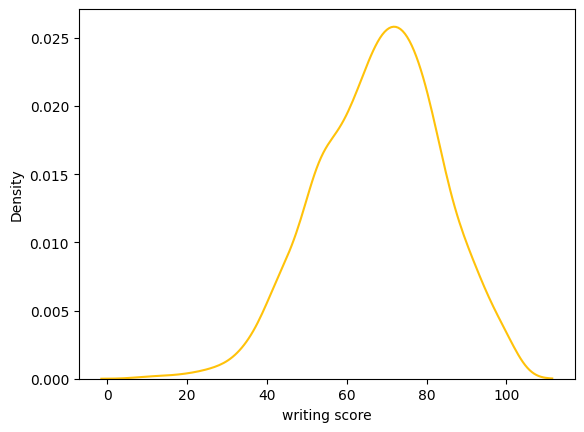

In [40]:
sns.kdeplot(data=df,x='writing score',color=pal[np.random.randint(0,5)])

<Axes: xlabel='writing score', ylabel='Density'>

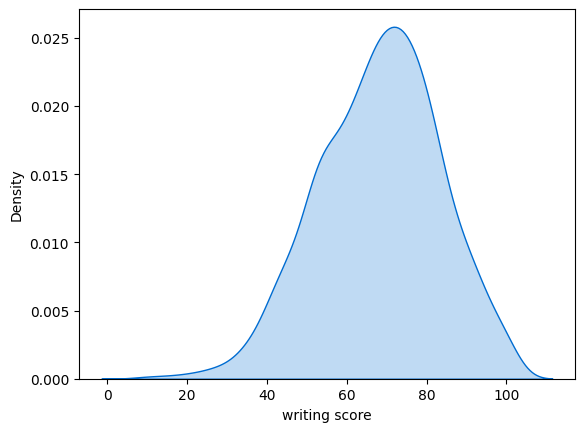

In [41]:
sns.kdeplot(data=df,x='writing score',color=pal[np.random.randint(0,5)],fill=True)

<Axes: xlabel='writing score', ylabel='Density'>

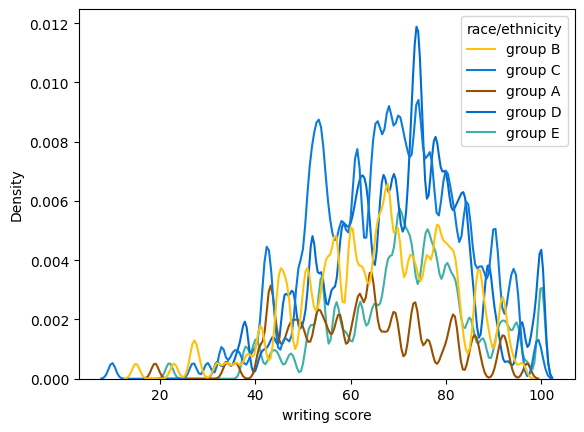

In [42]:
sns.kdeplot(data=df,
            x='writing score',
            hue = 'race/ethnicity',
            bw_method = .05,
            palette=pal[:-2])

<Axes: xlabel='writing score', ylabel='Density'>

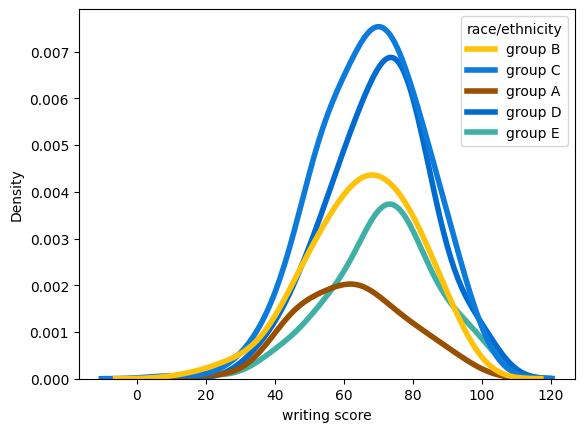

In [43]:
sns.kdeplot(data=df,
            x='writing score',
            hue = 'race/ethnicity',
            bw_method = .45,
            lw=4,
            palette=pal[:-2])

## Understanding the KDE Plot and Bandwidth (`bw_method`)

This graph is called a **Kernel Density Estimate (KDE) plot**. Think of it as a smoothed-out, continuous version of the histograms we were just looking at. 

Instead of dropping scores into rigid buckets (bars), a KDE plot draws a flowing curve to show the probability density of where the data is concentrated. 
* **The Peaks:** Where a line is highest (like around the 70-80 mark for the dark blue Group D), that is where the highest concentration of students' scores are clustered for that specific group.
* **The Valleys:** Where the line drops close to zero, very few students in that group received those scores.

However, you probably notice that these lines look incredibly jagged and nervous, almost like a heart rate monitor. This happens because of the bandwidth setting.


### The Significance of `bw_method` (Bandwidth)

The `bw_method` parameter controls the **bandwidth**, which dictates exactly how smooth or "wiggly" your curve is. Adjusting the bandwidth in a KDE plot is the exact same concept as changing the number of `bins` in a regular histogram.

* **Too Small (What is happening in your graph):** When the bandwidth is set to a very small number, the algorithm looks *too closely* at the data. It tries to draw a tiny peak for almost every single individual student's score. It captures all the random noise instead of the overall trend. This is called "undersmoothing."
* **Too Large:** If the bandwidth is set too high, the curve becomes overly smoothed out, flattening important peaks and hiding real, distinct patterns in your data ("oversmoothing").
* **Just Right:** The goal is to find a middle ground where the curve smooths out the meaningless random spikes (the noise) but still clearly shows the true shape, peaks, and valleys of your data's distribution.

## Boxplot

<Axes: xlabel='reading score'>

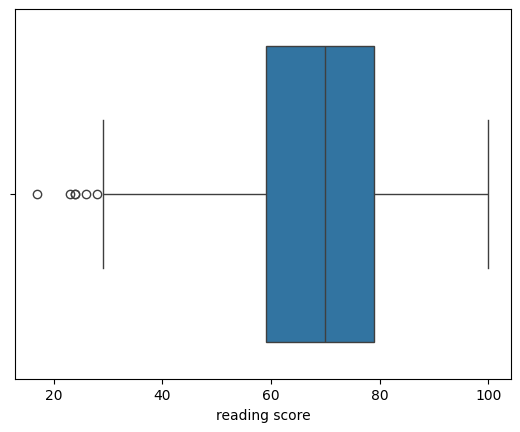

In [44]:
sns.boxplot(data=df,x='reading score')

In [45]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

<Axes: xlabel='reading score', ylabel='test preparation course'>

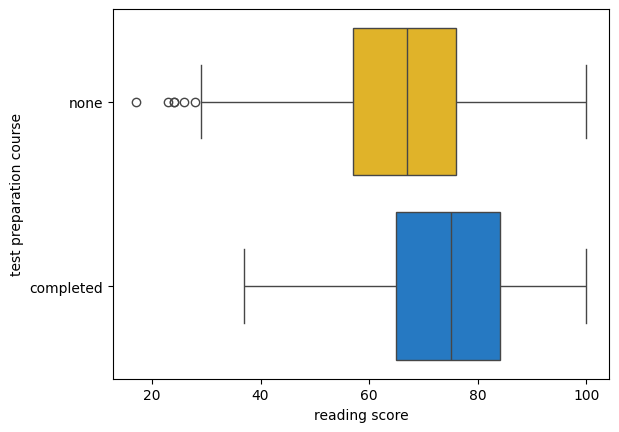

In [46]:
sns.boxplot(data=df,
            x='reading score',
           y='test preparation course',
            hue= 'test preparation course',
           palette = pal[0:2])

/tmp/ipykernel_17/1640229424.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,


<Axes: xlabel='reading score', ylabel='test preparation course'>

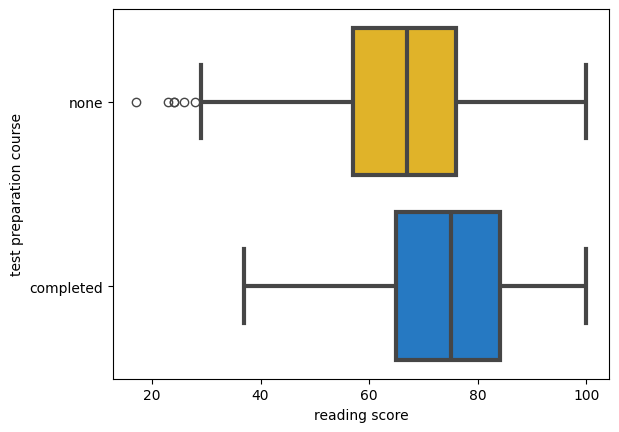

In [47]:
sns.boxplot(data=df,
            x='reading score',
            y='test preparation course',
            #hue= 'reading score',
            linewidth=3,
            legend=False,
            palette = pal[0:2])

## Understanding the `palette` and `hue` FutureWarning

Just like the last warning, this is **not an error**. Your code still executed, and your boxplot was created. A `FutureWarning` is simply Python's way of giving you a heads-up that the rules of the Seaborn library are going to change in an upcoming update, and you should probably update your code habits now to prevent things from breaking later.

### What it means

Historically, if you wanted to make every box in a boxplot a different color, you could just pass a list of colors to the `palette` argument. 

However, Seaborn's developers have decided that moving forward, `palette` should *only* be used when you are explicitly splitting your data into color-coded groups using the `hue` argument. Because you passed colors without defining a `hue` group, Seaborn is letting you know this shortcut will eventually be removed.

### How to fix it

The warning message actually gives you the exact solution! To get the exact same colorful boxplot without triggering the warning, you just need to set the categorical variable you are plotting (usually your `x` or `y` axis) as your `hue` as well, and then turn off the legend so it doesn't create a redundant box on your chart.

Here is what the code change looks like:

```python
# The old way (triggers the warning)
sns.boxplot(data=df, x='parental level of education', y='math score', palette=pal)

# The new, future-proof way (no warning)
sns.boxplot(data=df, x='parental level of education', y='math score', hue='parental level of education', palette=pal, legend=False)

/tmp/ipykernel_17/1110335588.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,


<Axes: xlabel='reading score', ylabel='test preparation course'>

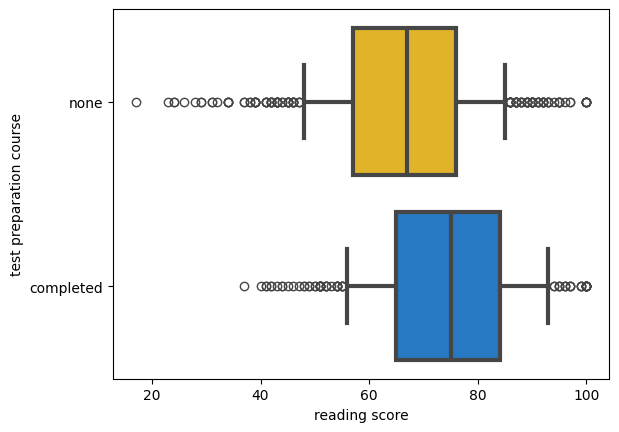

In [48]:
sns.boxplot(data=df,
            x='reading score',
            y='test preparation course',
           # hue= 'reading score',
            linewidth=3,
             whis=.5,
            palette = pal[0:2])

# violine plot

<Axes: ylabel='reading score'>

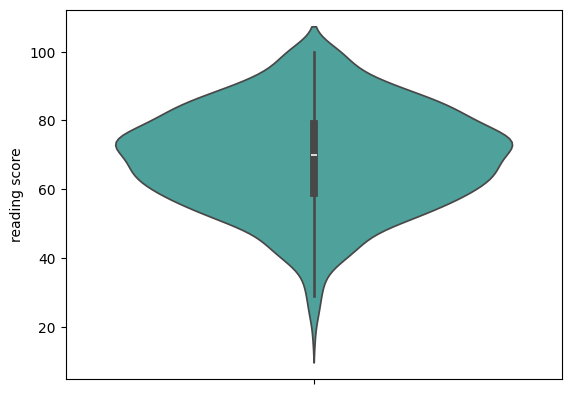

In [49]:
sns.violinplot(data=df,y='reading score',color=pal[4])

## Understanding the Violin Plot

This interesting-looking chart is called a **Violin Plot**. You can think of it as a mashup between a standard box plot and the smooth KDE (density) plots we looked at earlier. It is an excellent tool for data visualization because it gives you the best of both worlds in a single graphic!


Here is how to read the different parts of this specific graph:

### 1. The Shape (The "Violin")
The outer colored shape shows you the density or distribution of your data. 
* **Wider sections:** Where the shape is thickest (around a reading score of 70-75), that means a high concentration of students received those exact scores. 
* **Skinny sections:** The long, narrow tail stretching down to the 10-20 range tells you that very few students got exceptionally low reading scores.

### 2. The Inside (The Hidden Box Plot)
Look closely at the dark markings running down the center of the shape. That is actually a miniature box plot!
* **The White Dot:** This represents the **median** (the exact middle score). It looks like the median reading score for this group is right around 70.
* **The Thick Dark Bar:** This represents the **Interquartile Range (IQR)**, which contains the middle 50% of all your students. You can quickly see that the bulk of your class scored somewhere between 60 and 80.
* **The Thin Dark Line:** These act like the "whiskers" on a standard box plot, showing the rest of the typical score distribution before getting into extreme outliers.

<Axes: xlabel='gender', ylabel='reading score'>

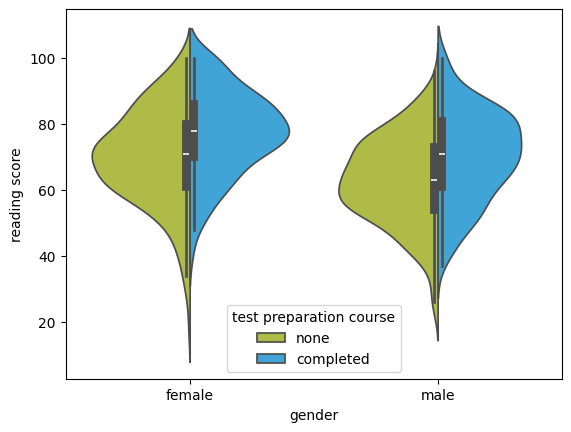

In [50]:
sns.violinplot(data=df,x='gender',y='reading score',hue='test preparation course',split=True,palette=pal[-2:])

/tmp/ipykernel_17/651954046.py:1: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method=0.2`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(data=df,x='gender',y='reading score',hue='test preparation course',inner='quartile',bw=.2,split=True,palette=pal[-2:])


<Axes: xlabel='gender', ylabel='reading score'>

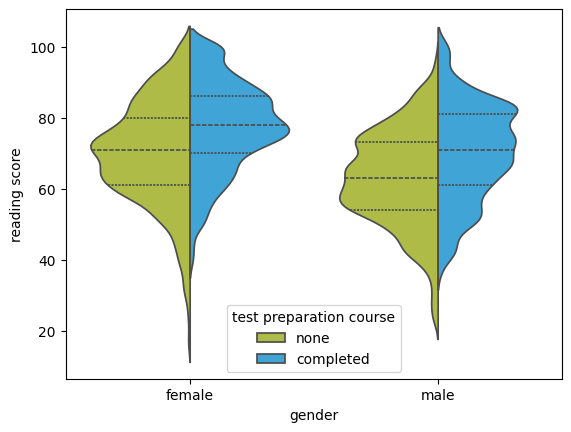

In [51]:
sns.violinplot(data=df,x='gender',y='reading score',hue='test preparation course',inner='quartile',bw=.2,split=True,palette=pal[-2:])

/tmp/ipykernel_17/191014130.py:1: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method=0.05`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(data=df,x='gender',y='reading score',hue='test preparation course',inner='stick',bw=.05,split=True,palette=pal[-2:])


<Axes: xlabel='gender', ylabel='reading score'>

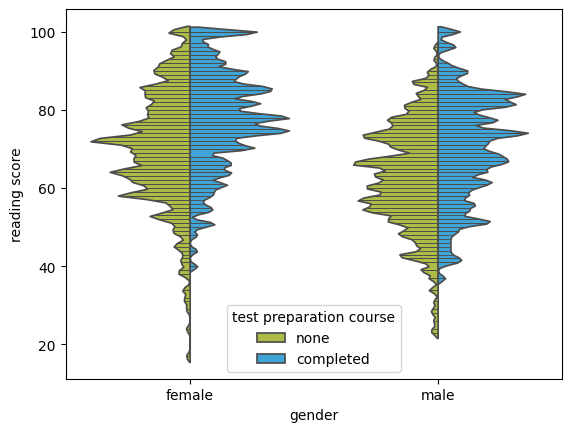

In [52]:
sns.violinplot(data=df,x='gender',y='reading score',hue='test preparation course',inner='stick',bw=.05,split=True,palette=pal[-2:])

# Boxenplot

In [53]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

<Axes: xlabel='writing score'>

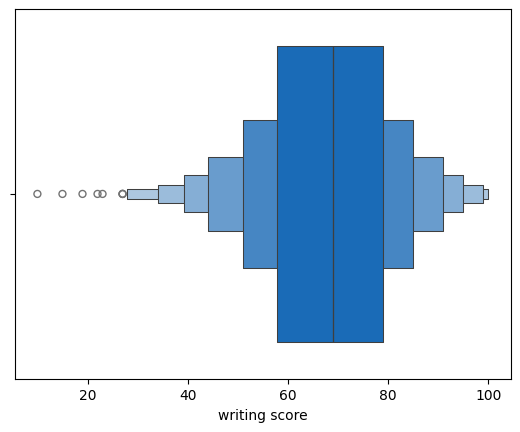

In [54]:
sns.boxenplot(data=df,x='writing score',color=pal[3])

<Axes: xlabel='writing score'>

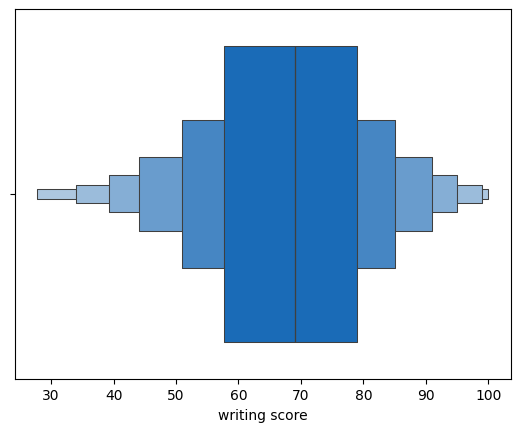

In [55]:
sns.boxenplot(data=df,x='writing score',showfliers=False,color=pal[3])

## Understanding the Boxen Plot (Letter-Value Plot)

This unique, blocky chart is called a **Boxen Plot** (also known in statistics as a Letter-Value plot). Think of it as a highly upgraded version of a standard box plot, specifically designed to handle larger datasets. 

While a regular box plot only shows you the middle 50% of your data and dumps the rest into thin "whiskers" or outlier dots, a boxen plot gives you a much better picture of the actual shape and spread at the extremes (the tails) of your data.


Here is how to read the different blocks:

* **The Center Block:** The thickest, darkest box right in the middle represents the **Interquartile Range (IQR)**—the middle 50% of all the students' writing scores. The dark vertical line cutting down the center of this block is the **median** score (which looks to be around 68-70).
* **The Stepping Stones:** As you move outward from the center, each new, slightly thinner and lighter block represents half of the remaining data. 
    * The first step outward covers the next 12.5% of the data on each side.
    * The next step covers the next 6.25%, and so on, gradually tapering off.
* **The Outliers:** Eventually, the mathematical blocks stop, and any remaining extreme data points are plotted as individual hollow circles on the far edges. You can see a handful of exceptionally low scores trailing off into the 10-20 range on the left.

### Why use this over a normal Box Plot?
If you have a dataset with hundreds or thousands of rows, a standard box plot might label way too many perfectly valid data points as "outliers," which can be misleading. A boxen plot solves this by plotting more percentiles, showing you the true density of those high and low scores instead of just a straight line.

<Axes: xlabel='writing score', ylabel='gender'>

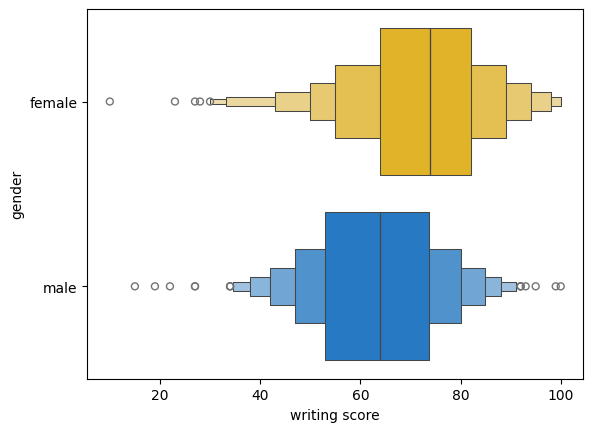

In [56]:
sns.boxenplot(data=df,
              x='writing score',
              y='gender',
              hue = 'gender',
              label = False,
              showfliers=True,
              palette=pal[:2]) 

<Axes: xlabel='writing score', ylabel='gender'>

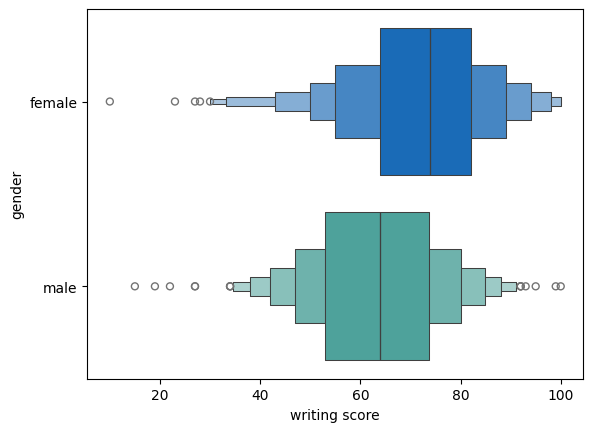

In [57]:
sns.boxenplot(data=df,
              x='writing score',
              y='gender',
              hue = 'gender',
              legend= False,
              showfliers=True,
              #width_method='area',
              palette=pal[3:5]) 

# Swarm plot

In [58]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

<Axes: xlabel='reading score', ylabel='gender'>

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 8.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 6.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


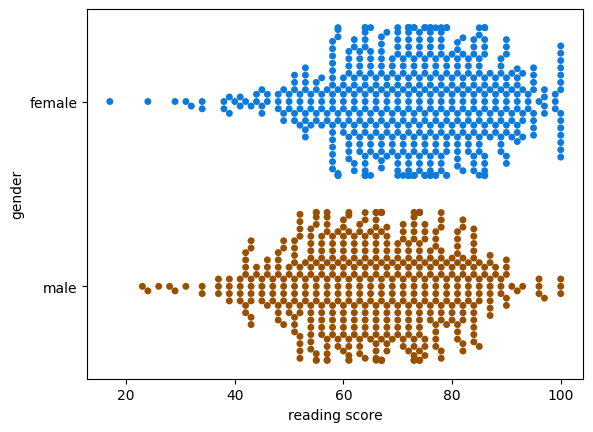

In [59]:
sns.swarmplot(data=df,x='reading score',y='gender',hue='gender',palette=pal[1:3])

<Axes: xlabel='gender', ylabel='reading score'>

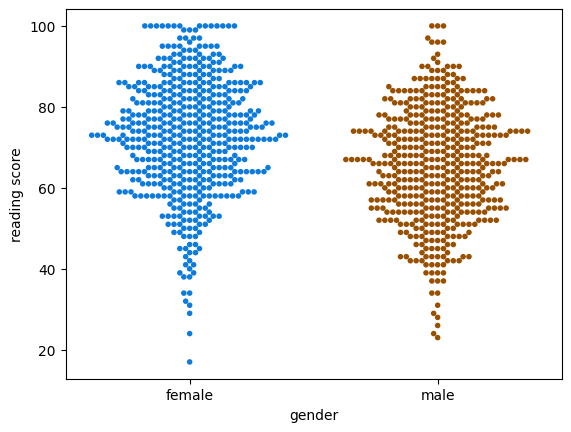

In [60]:
sns.swarmplot(data=df,y='reading score',x='gender',hue='gender',size=4,palette=pal[1:3])

<Axes: xlabel='gender', ylabel='reading score'>

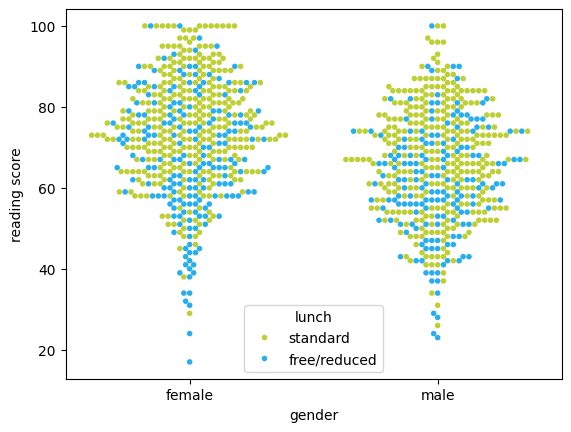

In [61]:
sns.swarmplot(data=df,y='reading score',x='gender',hue='lunch',size=4,palette=pal[5:7])

# countplot

/tmp/ipykernel_17/369650326.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x='gender',palette=[pal[4],pal[5]])


<Axes: xlabel='gender', ylabel='count'>

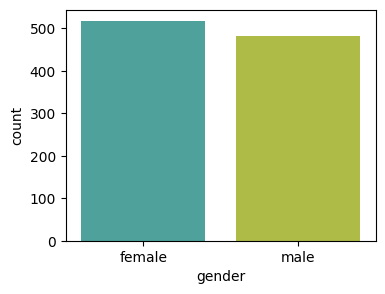

In [62]:
plt.figure(figsize=(4,3))
sns.countplot(data=df,x='gender',palette=[pal[4],pal[5]])

In [63]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

/tmp/ipykernel_17/4170209968.py:2: UserWarning: The palette list has more values (7) than needed (5), which may not be intended.
  sns.countplot(data=df,x='race/ethnicity',hue='race/ethnicity',palette=pal)


<Axes: xlabel='race/ethnicity', ylabel='count'>

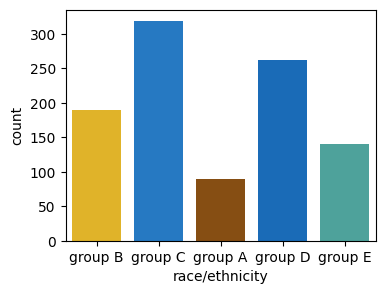

In [64]:
plt.figure(figsize=(4,3))
sns.countplot(data=df,x='race/ethnicity',hue='race/ethnicity',palette=pal)

/tmp/ipykernel_17/4070493156.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x='lunch',palette=pal[-2:])


<Axes: xlabel='lunch', ylabel='count'>

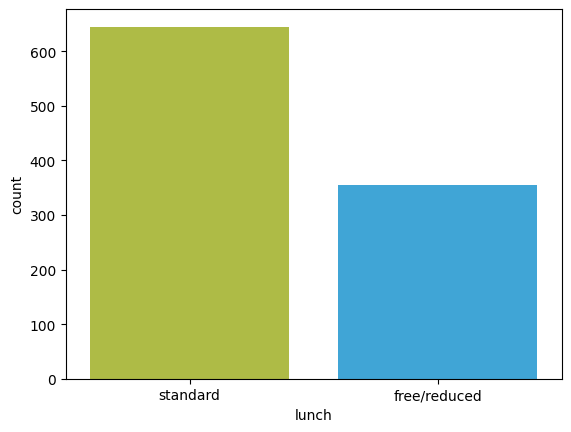

In [65]:
sns.countplot(data=df,x='lunch',palette=pal[-2:])

<Axes: xlabel='lunch', ylabel='count'>

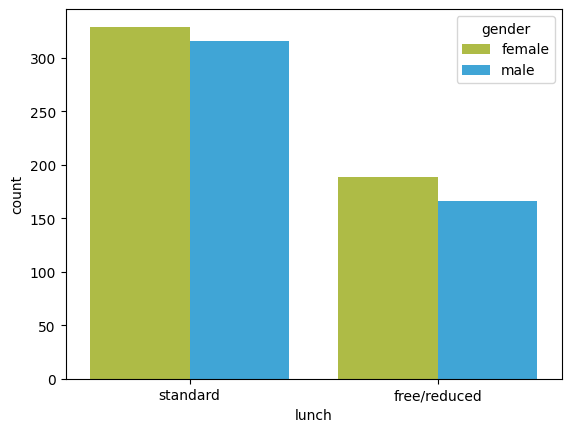

In [66]:
sns.countplot(data=df,x='lunch',hue='gender',dodge=True,palette=pal[-2:])

# figure level plot
# seaborn distplot

In [67]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

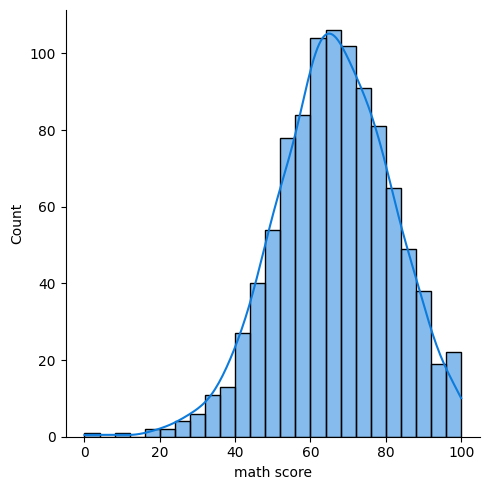

In [68]:
sns.displot(data=df,x='math score',kde=True,color=pal[np.random.randint(0,5)])

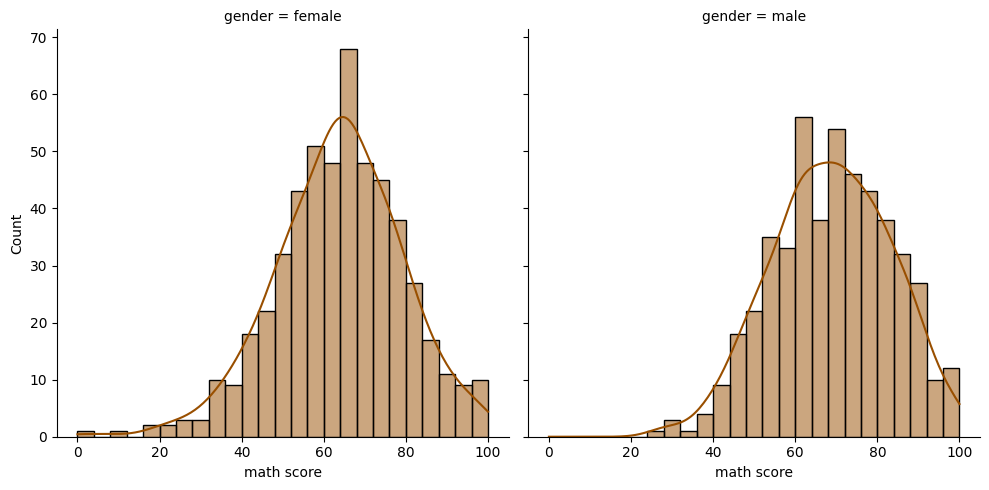

In [69]:
sns.displot(data=df,x='math score',kde=True,col='gender',color=pal[np.random.randint(0,5)])

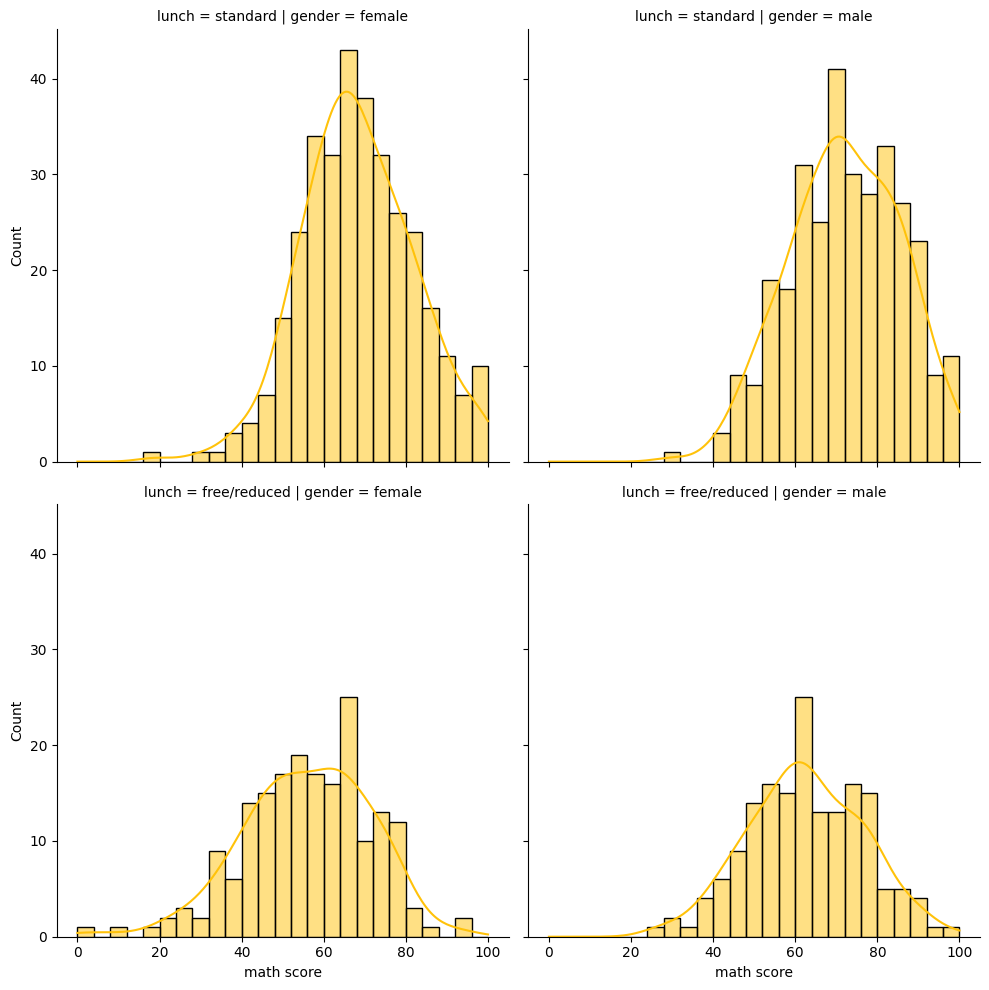

In [70]:
sns.displot(data=df,x='math score',kde=True,col='gender',row='lunch',color=pal[np.random.randint(0,5)])

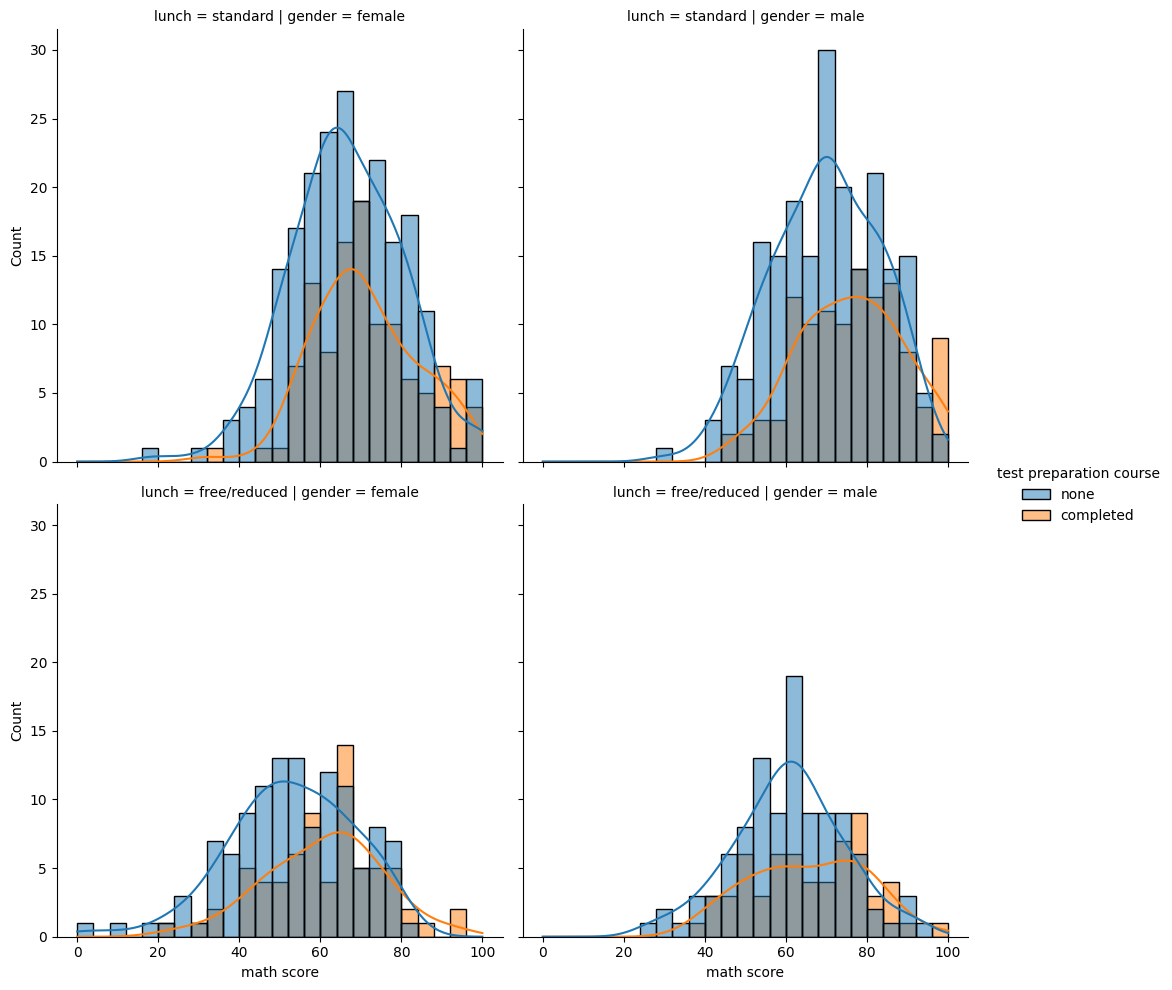

In [71]:
sns.displot(data=df,x='math score',kde=True,col='gender',row='lunch',hue='test preparation course',color=pal[np.random.randint(0,5)])

In [72]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

# Seaborn catplot

/tmp/ipykernel_17/4182231046.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data=df,kind='strip',x='math score',y='lunch',height=3.5,palette=[pal[np.random.randint(0,5)],pal[np.random.randint(0,5)]])


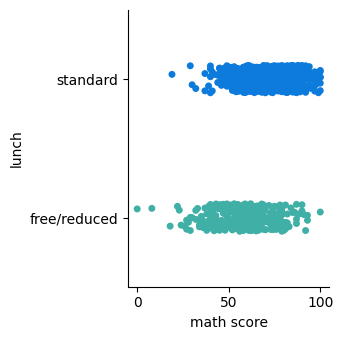

In [73]:
sns.catplot(data=df,kind='strip',x='math score',y='lunch',height=3.5,palette=[pal[np.random.randint(0,5)],pal[np.random.randint(0,5)]])

/tmp/ipykernel_17/3099952732.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data=df,


/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 29.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 28.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


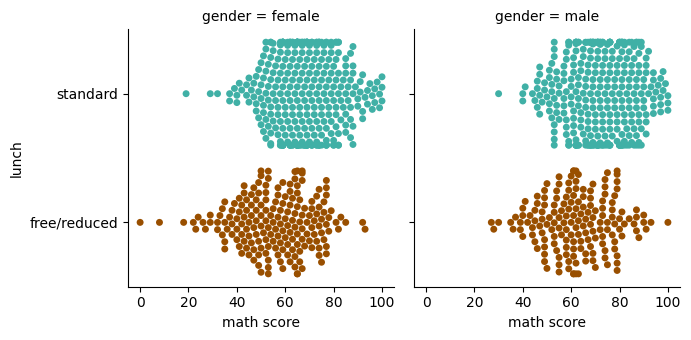

In [74]:
sns.catplot(data=df,
            kind='swarm',
            x='math score',
            y='lunch',
            col='gender',
            height=3.5,
            palette=[pal[np.random.randint(0,5)],pal[np.random.randint(0,5)]])

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 10.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 8.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 10.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 8.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


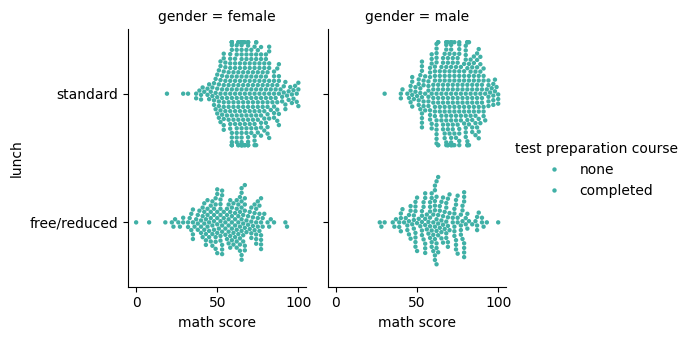

In [75]:
sns.catplot(data=df,
            kind='swarm',
            x='math score',
            y='lunch',
            hue='test preparation course',
            col='gender',
            height=3.5,
            aspect=.8,
            s=10,
            palette=[pal[np.random.randint(0,5)],pal[np.random.randint(0,5)]])

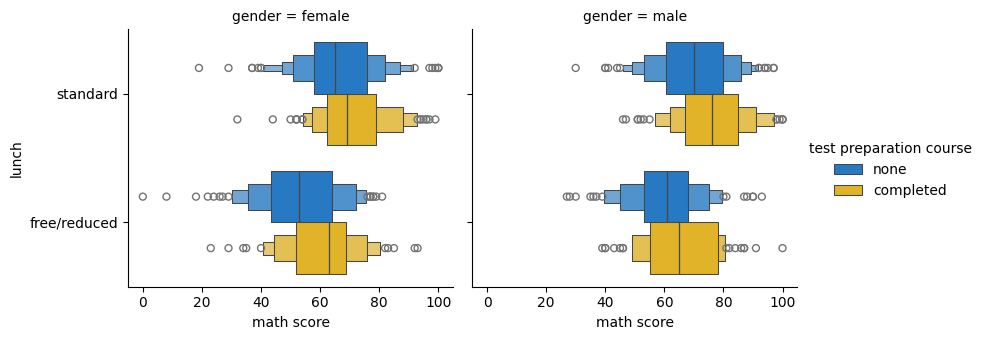

In [76]:
sns.catplot(data=df,
            kind='boxen',
            x='math score',
            y='lunch',
            hue='test preparation course',
            col='gender',
            height=3.5,
            aspect=1.2,
            #s=10,
            palette=[pal[np.random.randint(0,5)],pal[np.random.randint(0,5)]])

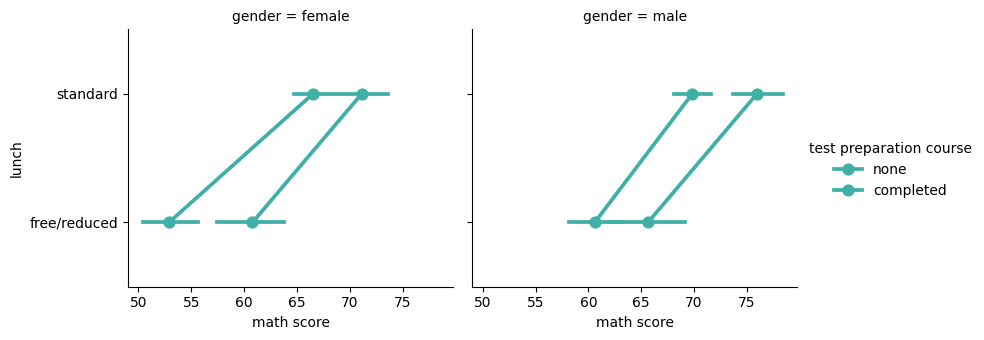

In [77]:
sns.catplot(data=df,
            kind='point',
            x='math score',
            y='lunch',
            hue='test preparation course',
            col='gender',
            height=3.5,
            aspect=1.2,
            #s=10,
            palette=[pal[np.random.randint(0,5)],pal[np.random.randint(0,5)]])

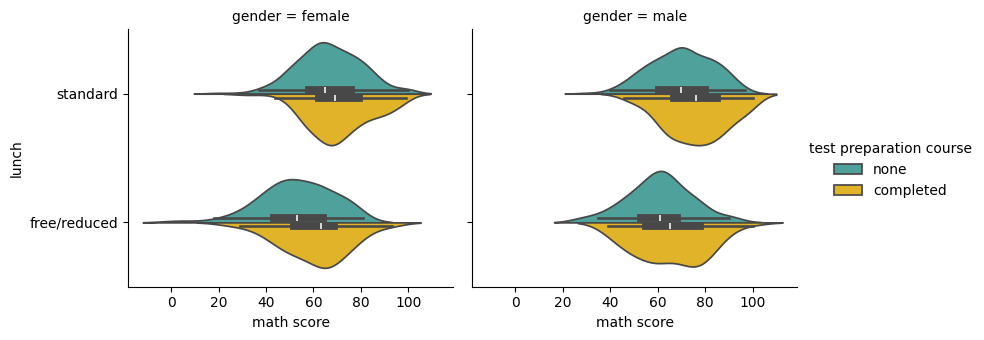

In [78]:
sns.catplot(data=df,
            kind='violin',
            x='math score',
            y='lunch',
            hue='test preparation course',
            col='gender',
            height=3.5,
            aspect=1.2,
            split=True,
            palette=[pal[np.random.randint(0,5)],pal[np.random.randint(0,5)]])

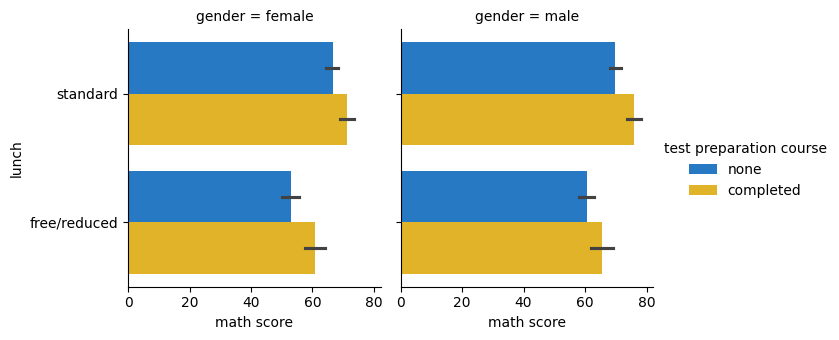

In [79]:
sns.catplot(data=df,
            kind='bar',
            x='math score',
            y='lunch',
            hue='test preparation course',
            col='gender',
            height=3.5,
            #aspect=1.2,
            #split=True,
            palette=[pal[np.random.randint(0,5)],pal[np.random.randint(0,5)]])